<a href="https://colab.research.google.com/github/Sujal2424/AI/blob/main/Radial_compressor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

# =====================================================
#                USER INPUTS (Interactive)
# =====================================================

print("\n--- GAS PROPERTIES ---")
gamma = float(input("Enter gamma (e.g. 1.4): "))
R = float(input("Enter gas constant R (e.g. 287): "))
cp = float(input("Enter cp (e.g. 1005): "))
T1 = float(input("Enter inlet temperature T1 (K): "))

print("\n--- MATERIAL PROPERTIES ---")
rho_mat = float(input("Enter material density (kg/m3): "))
nu = float(input("Enter Poisson ratio (e.g. 0.3): "))
stress_limit = float(input("Enter stress limit (Pa): "))

print("\n--- OPERATING LIMITS ---")
PR_min = float(input("Enter minimum Pressure Ratio: "))
PR_max = float(input("Enter maximum Pressure Ratio: "))

rpm_min = float(input("Enter minimum RPM: "))
rpm_max = float(input("Enter maximum RPM: "))

tip_speed_limit = float(input("Enter tip speed limit (m/s): "))
mach_limit = float(input("Enter Mach limit at tip: "))

print("\n--- FLOW & SURGE ---")
phi_design = float(input("Enter design flow coefficient (e.g. 0.15): "))
phi_surge = float(input("Enter surge flow coefficient (e.g. 0.08): "))
surge_margin_min = float(input("Enter minimum surge margin (e.g. 0.1): "))

print("\n--- DESIGN RANGES ---")
D2_min = float(input("Enter minimum D2 (m): "))
D2_max = float(input("Enter maximum D2 (m): "))
rpm_points = int(input("Number of RPM sweep points: "))
beta_points = int(input("Number of Beta2 sweep points: "))
phi_points = int(input("Number of Phi sweep points: "))

print("\n--- OPTIMIZATION WEIGHTS ---")
w_PR = float(input("Weight for PR: "))
w_eta = float(input("Weight for Efficiency: "))
w_stress = float(input("Weight for Stress penalty: "))
w_mach = float(input("Weight for Mach penalty: "))

# =====================================================
#              SETUP SWEEP ARRAYS
# =====================================================

D2_range = np.linspace(D2_min, D2_max, 20)
rpm_range = np.linspace(rpm_min, rpm_max, rpm_points)
beta2_range = np.linspace(30, 60, beta_points)
phi_range = np.linspace(phi_surge, 0.25, phi_points)

a1 = np.sqrt(gamma * R * T1)

valid_designs = []

# =====================================================
#                GENERATIVE LOOP
# =====================================================

for D2 in D2_range:
    r2 = D2 / 2

    for rpm in rpm_range:
        omega = 2 * np.pi * rpm / 60
        U2 = omega * r2

        if U2 > tip_speed_limit:
            continue

        sigma_max = ((3 + nu) / 8) * rho_mat * omega**2 * r2**2
        if sigma_max > stress_limit:
            continue

        M_tip = U2 / a1
        if M_tip > mach_limit:
            continue

        for beta2 in beta2_range:
            beta2_rad = np.radians(beta2)

            for phi in phi_range:

                Vf2 = phi * U2

                surge_margin = (phi - phi_surge) / phi_design
                if surge_margin < surge_margin_min:
                    continue

                Vw2 = U2 - Vf2 / np.tan(beta2_rad)
                delta_h = U2 * Vw2

                eta = 0.9 - 1.2*(phi - phi_design)**2 - 0.05*M_tip**2
                if eta <= 0 or eta > 0.92:
                    continue

                PR = (1 + (eta * delta_h) / (cp * T1)) ** (gamma / (gamma - 1))

                if PR < PR_min or PR > PR_max:
                    continue

                valid_designs.append([
                    D2, rpm, beta2, phi,
                    U2, sigma_max, M_tip,
                    eta, PR, surge_margin
                ])

# =====================================================
#                RESULTS
# =====================================================

columns = ["D2 (m)", "RPM", "Beta2 (deg)", "Phi",
           "Tip Speed (m/s)", "Stress (Pa)", "Mach Tip",
           "Efficiency", "Pressure Ratio", "Surge Margin"]

df = pd.DataFrame(valid_designs, columns=columns)

print("\nTotal Valid Designs Found:", len(df))

if len(df) > 0:

    df["PR_norm"] = (df["Pressure Ratio"] - df["Pressure Ratio"].min()) / \
                    (df["Pressure Ratio"].max() - df["Pressure Ratio"].min())

    df["eta_norm"] = (df["Efficiency"] - df["Efficiency"].min()) / \
                     (df["Efficiency"].max() - df["Efficiency"].min())

    df["stress_norm"] = (df["Stress (Pa)"] - df["Stress (Pa)"].min()) / \
                        (df["Stress (Pa)"].max() - df["Stress (Pa)"].min())

    df["Mach_norm"] = (df["Mach Tip"] - df["Mach Tip"].min()) / \
                      (df["Mach Tip"].max() - df["Mach Tip"].min())

    df["Score"] = (w_PR * df["PR_norm"] +
                   w_eta * df["eta_norm"] -
                   w_stress * df["stress_norm"] -
                   w_mach * df["Mach_norm"])

    best_design = df.sort_values("Score", ascending=False).iloc[0]

    print("\nBest Optimized Design:\n")
    print(best_design)

    df.to_csv("optimized_radial_compressor_designs.csv", index=False)

else:
    print("No feasible design found. Try relaxing constraints.")


--- GAS PROPERTIES ---
Enter gamma (e.g. 1.4): 1.4
Enter gas constant R (e.g. 287): 287
Enter cp (e.g. 1005): 1005
Enter inlet temperature T1 (K): 288

--- MATERIAL PROPERTIES ---
Enter material density (kg/m3): 8000
Enter Poisson ratio (e.g. 0.3): 0.3
Enter stress limit (Pa): 300000000

--- OPERATING LIMITS ---
Enter minimum Pressure Ratio: 2.5
Enter maximum Pressure Ratio: 3
Enter minimum RPM: 39600
Enter maximum RPM: 48400
Enter tip speed limit (m/s): 380
Enter Mach limit at tip: 1

--- FLOW & SURGE ---
Enter design flow coefficient (e.g. 0.15): 0.15
Enter surge flow coefficient (e.g. 0.08): 0.08
Enter minimum surge margin (e.g. 0.1): 0.1

--- DESIGN RANGES ---
Enter minimum D2 (m): 0.08
Enter maximum D2 (m): 0.18
Number of RPM sweep points: 20
Number of Beta2 sweep points: 20
Number of Phi sweep points: 20

--- OPTIMIZATION WEIGHTS ---
Weight for PR: 0.4
Weight for Efficiency: 0.3
Weight for Stress penalty: 0.2
Weight for Mach penalty: 0.1

Total Valid Designs Found: 0
No feasible

vista ccd


In [ ]:
import numpy as np

print("\n========== RADIAL COMPRESSOR MEAN-LINE DESIGN TOOL ==========\n")

# =========================
# USER INPUTS
# =========================
gamma = float(input("Gamma (e.g. 1.4): "))
R = float(input("Gas constant R (287 for air): "))
cp = float(input("cp (J/kgK): "))
T1 = float(input("Inlet Temperature T1 (K): "))
P1 = float(input("Inlet Pressure P1 (Pa): "))
m_dot = float(input("Mass flow rate (kg/s): "))
PR_target = float(input("Target Pressure Ratio: "))
RPM = float(input("Design RPM: "))
eta_is = float(input("Isentropic Efficiency (0.75-0.9): "))
Z = int(input("Number of impeller blades (e.g. 12): "))
psi_guess = float(input("Initial loading coefficient guess (0.6-0.8): "))
rho_mat = float(input("Material density (kg/m3): "))
stress_limit = float(input("Allowable stress (Pa): "))

# =========================
# BASIC PROPERTIES
# =========================
rho1 = P1 / (R * T1)
a1 = np.sqrt(gamma * R * T1)

# Required isentropic work
delta_h_is = cp * T1 * (PR_target**((gamma-1)/gamma) - 1)
delta_h_required = delta_h_is / eta_is

print("\nRequired specific work:", round(delta_h_required,2), "J/kg")

# =========================
# ITERATIVE SOLVER
# =========================

psi = psi_guess
error = 1
tolerance = 1e-3
iteration = 0

while abs(error) > tolerance and iteration < 100:

    # Tip speed from loading
    U2 = np.sqrt(delta_h_required / psi)

    # Diameter from RPM
    D2 = (60 * U2) / (np.pi * RPM)

    # Assume exit blade height ratio
    phi_target = 0.15
    b2 = m_dot / (rho1 * np.pi * D2 * U2 * phi_target)

    # Flow area
    A2 = np.pi * D2 * b2

    # Radial velocity
    Vr2 = m_dot / (rho1 * A2)

    phi = Vr2 / U2

    # Ideal whirl
    Vw2_ideal = U2

    # Wiesner slip factor
    sigma_slip = 1 - (np.pi / Z)

    Vw2 = sigma_slip * Vw2_ideal

    # Euler work
    delta_h_actual = U2 * Vw2

    # Actual PR
    PR_actual = (1 + (eta_is * delta_h_actual) / (cp * T1))**(gamma/(gamma-1))

    error = PR_actual - PR_target

    psi += error * 0.05   # relaxation update

    iteration += 1

# =========================
# FINAL CALCULATIONS
# =========================
Mach_tip = U2 / a1
stress = rho_mat * U2**2
Ns = RPM * np.sqrt(m_dot) / (delta_h_required**0.75)

# =========================
# OUTPUT
# =========================

print("\n========== DESIGN RESULTS ==========")
print(f"Iterations: {iteration}")
print(f"Impeller Diameter D2: {D2*1000:.2f} mm")
print(f"Blade height b2: {b2*1000:.2f} mm")
print(f"Tip Speed U2: {U2:.2f} m/s")
print(f"Flow Coefficient φ: {phi:.3f}")
print(f"Loading Coefficient ψ: {psi:.3f}")
print(f"Slip Factor σ: {sigma_slip:.3f}")
print(f"Predicted PR: {PR_actual:.3f}")
print(f"Tip Mach: {Mach_tip:.3f}")
print(f"Estimated Stress: {stress/1e6:.2f} MPa")
print(f"Specific Speed Ns: {Ns:.3f}")

print("\n========== DESIGN CHECKS ==========")

if 0.05 < phi < 0.25:
    print("Flow coefficient OK")
else:
    print("Flow coefficient OUT OF RANGE")

if Mach_tip < 1.2:
    print("Mach OK")
else:
    print("Mach TOO HIGH")

if stress < stress_limit:
    print("Stress OK")
else:
    print("Stress EXCEEDS LIMIT")

if 0.5 < psi < 0.9:
    print("Loading reasonable")
else:
    print("Loading outside typical range")

print("\nDesign Complete.\n")


========== RADIAL COMPRESSOR MEAN-LINE DESIGN TOOL ==========

Gamma (e.g. 1.4): 1.4
Gas constant R (287 for air): 287
cp (J/kgK): 1005
Inlet Temperature T1 (K): 288
Inlet Pressure P1 (Pa): 101325
Mass flow rate (kg/s): 1.56
Target Pressure Ratio: 2.6
Design RPM: 44000
Isentropic Efficiency (0.75-0.9): 0.85
Number of impeller blades (e.g. 12): 12
Initial loading coefficient guess (0.6-0.8): 07
Material density (kg/m3): 4430
Allowable stress (Pa): 900000000

Required specific work: 106890.04 J/kg

========== DESIGN RESULTS ==========
Iterations: 100
Impeller Diameter D2: 148.79 mm
Blade height b2: 52.95 mm
Tip Speed U2: 342.79 m/s
Flow Coefficient φ: 0.150
Loading Coefficient ψ: 0.890
Slip Factor σ: 0.738
Predicted PR: 2.213
Tip Mach: 1.008
Estimated Stress: 520.56 MPa
Specific Speed Ns: 9.296

========== DESIGN CHECKS ==========
Flow coefficient OK
Mach OK
Stress OK
Loading reasonable

Design Complete.



LETS GO FOR PARAMETERING AND AI


In [ ]:
import numpy as np
import pandas as pd

print("\n===== PHASE 1: PARAMETRIC MULTI-OBJECTIVE STUDY =====\n")

# ---------------- FIXED REQUIREMENTS ----------------
gamma = 1.4
R = 287
cp = 1005
T1 = 288
P1 = 101325
m_dot = 1.56
PR_target = 2.6
eta_is = 0.85
rho_mat = 4430
stress_limit = 900e6

rho1 = P1 / (R * T1)
a1 = np.sqrt(gamma * R * T1)

delta_h_required = (cp*T1*(PR_target**((gamma-1)/gamma)-1))/eta_is

# ---------------- DESIGN SPACE ----------------
RPM_range = np.linspace(40000, 60000, 20)
psi_range = np.linspace(0.6, 0.95, 20)
Z_range = [10,12,14,16]
phi_target_range = np.linspace(0.12, 0.2, 10)

designs = []

for RPM in RPM_range:
    for psi in psi_range:
        for Z in Z_range:
            for phi_target in phi_target_range:

                # Tip speed
                U2 = np.sqrt(delta_h_required / psi)

                # Diameter
                D2 = (60 * U2) / (np.pi * RPM)

                # Blade height from phi target
                b2 = m_dot / (rho1 * np.pi * D2 * U2 * phi_target)

                # Slip factor (Wiesner)
                sigma_slip = 1 - (np.pi / Z)

                # Actual work
                delta_h_actual = U2 * (sigma_slip * U2)

                PR_actual = (1 + (eta_is * delta_h_actual) /
                            (cp*T1))**(gamma/(gamma-1))

                Mach_tip = U2 / a1
                stress = rho_mat * U2**2

                # Constraints
                if (0.1 < phi_target < 0.2 and
                    Mach_tip < 1.2 and
                    stress < stress_limit):

                    designs.append([
                        RPM, psi, Z, phi_target,
                        D2, b2, U2,
                        PR_actual, Mach_tip, stress
                    ])

# ---------------- RESULTS ----------------
columns = ["RPM","psi","Z","phi",
           "D2","b2","U2",
           "PR","Mach","Stress"]

df = pd.DataFrame(designs, columns=columns)

print("Total Feasible Designs:", len(df))

# Normalize for scoring
df["PR_n"] = (df["PR"] - df["PR"].min()) / (df["PR"].max() - df["PR"].min())
df["Stress_n"] = (df["Stress"] - df["Stress"].min()) / (df["Stress"].max() - df["Stress"].min())
df["Mach_n"] = (df["Mach"] - df["Mach"].min()) / (df["Mach"].max() - df["Mach"].min())
df["D2_n"] = (df["D2"] - df["D2"].min()) / (df["D2"].max() - df["D2"].min())

# Multi-objective score
df["Score"] = (0.4*df["PR_n"]
               -0.3*df["Stress_n"]
               -0.2*df["Mach_n"]
               -0.1*df["D2_n"])

best = df.sort_values("Score", ascending=False).iloc[0]

print("\n===== BEST DESIGN FROM PHASE 1 =====\n")
print(best)

df.to_csv("phase1_dataset.csv", index=False)
df.to_csv("/content/phase1_dataset.csv", index=False)

from google.colab import files
files.download("/content/phase1_dataset.csv")


===== PHASE 1: PARAMETRIC MULTI-OBJECTIVE STUDY =====

Total Feasible Designs: 12240

===== BEST DESIGN FROM PHASE 1 =====

RPM         6.000000e+04
psi         9.500000e-01
Z           1.600000e+01
phi         1.733333e-01
D2          1.067719e-01
b2          6.525092e-02
U2          3.354338e+02
PR          2.280205e+00
Mach        9.860651e-01
Stress      4.984451e+08
PR_n        2.181842e-01
Stress_n    0.000000e+00
Mach_n      0.000000e+00
D2_n        0.000000e+00
Score       8.727366e-02
Name: 12237, dtype: float64


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

phase 2

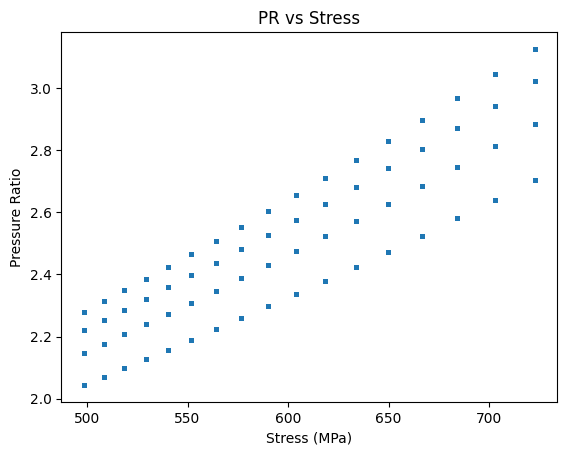

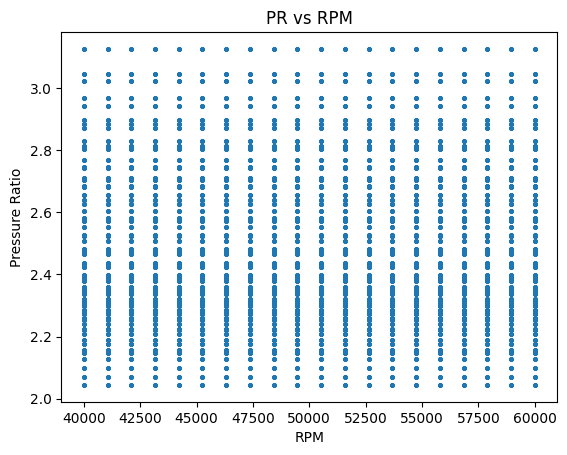

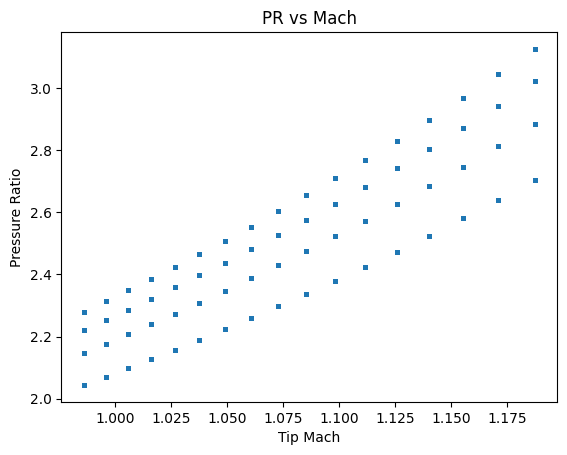

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ---- Load dataframe if needed ----
# df = pd.read_csv("/content/phase1_dataset.csv")

# Convert stress to MPa
df["Stress_MPa"] = df["Stress"] / 1e6

# -------------------------------
# 1️⃣ PR vs Stress
# -------------------------------
plt.figure()
plt.scatter(df["Stress_MPa"], df["PR"], s=5)
plt.xlabel("Stress (MPa)")
plt.ylabel("Pressure Ratio")
plt.title("PR vs Stress")
plt.show()

# -------------------------------
# 2️⃣ PR vs RPM
# -------------------------------
plt.figure()
plt.scatter(df["RPM"], df["PR"], s=5)
plt.xlabel("RPM")
plt.ylabel("Pressure Ratio")
plt.title("PR vs RPM")
plt.show()

# -------------------------------
# 3️⃣ PR vs Mach
# -------------------------------
plt.figure()
plt.scatter(df["Mach"], df["PR"], s=5)
plt.xlabel("Tip Mach")
plt.ylabel("Pressure Ratio")
plt.title("PR vs Mach")
plt.show()



pareto

Pareto points: 18


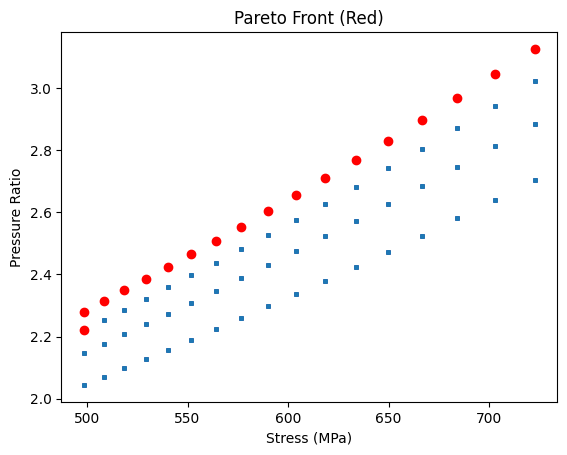

In [ ]:
# Faster Pareto extraction (2 objectives: PR max, Stress min)

df_sorted = df.sort_values(by="Stress")

pareto_points = []
max_pr_so_far = -np.inf

for _, row in df_sorted.iterrows():
    if row["PR"] > max_pr_so_far:
        pareto_points.append(row)
        max_pr_so_far = row["PR"]

pareto_df = pd.DataFrame(pareto_points)

print("Pareto points:", len(pareto_df))

plt.figure()
plt.scatter(df["Stress"]/1e6, df["PR"], s=5, alpha=0.2)
plt.scatter(pareto_df["Stress"]/1e6, pareto_df["PR"], color="red")
plt.xlabel("Stress (MPa)")
plt.ylabel("Pressure Ratio")
plt.title("Pareto Front (Red)")
plt.show()

AI learning optimization


In [ ]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features and targets
X = df[["RPM","psi","Z","phi"]].values
y = df[["PR","Stress","Mach","D2"]].values

# Split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

# Scale
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train = scaler_X.fit_transform(X_train)
X_test = scaler_X.transform(X_test)

y_train = scaler_y.fit_transform(y_train)
y_test = scaler_y.transform(y_test)

# Neural network
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(4)
])

model.compile(optimizer="adam", loss="mse")

model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=1)

loss = model.evaluate(X_test, y_test)
print("Test Loss:", loss)

Epoch 1/50
306/306 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.2847  
Epoch 2/50
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0021
Epoch 3/50
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0011
Epoch 4/50
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7.8827e-04
Epoch 5/50
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 6.3133e-04  
Epoch 6/50
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5.0092e-04
Epoch 7/50
306/306 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 4.2621e-04
Epoch 8/50
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3.5647e-04
Epoch 9/50
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3.2597e-04
Epoch 10/50
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.5520e-04
Epoch 11/50
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.2236e-04
Epoch 12/50
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.0178e-04
Epoch 13/50
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.8327e-04
Epoch 14/50
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.5430e-04
Epoch 15/

In [ ]:
!pip install pymoo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 328.3/328.3 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 kB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 5.2 MB/s eta 0:00:00


Phase 4


In [ ]:
import numpy as np
from pymoo.core.problem import Problem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.termination import get_termination

# Define problem
class CompressorProblem(Problem):

    def __init__(self):
        super().__init__(
            n_var=4,
            n_obj=4,
            n_constr=2,
            xl=np.array([40000, 0.6, 10, 0.12]),
            xu=np.array([60000, 0.95, 16, 0.2])
        )

    def _evaluate(self, X, out, *args, **kwargs):
        F = []
        G = []

        for x in X:
            RPM, psi, Z, phi = x
            Z = int(round(Z))

            X_input = scaler_X.transform([[RPM,psi,Z,phi]])
            pred = scaler_y.inverse_transform(model.predict(X_input,verbose=0))[0]
            PR, Stress, Mach, D2 = pred

            # Objectives (minimize)
            F.append([
                -PR,          # maximize PR
                Stress,       # minimize stress
                Mach,         # minimize Mach
                D2            # minimize diameter
            ])

            # Constraints
            G.append([
                Stress - 900e6,
                Mach - 1.2
            ])

        out["F"] = np.array(F)
        out["G"] = np.array(G)

problem = CompressorProblem()

algorithm = NSGA2(
    pop_size=100,
    sampling=FloatRandomSampling(),
    crossover=SBX(prob=0.9, eta=15),
    mutation=PM(eta=20),
    eliminate_duplicates=True
)

termination = get_termination("n_gen", 50)

res = minimize(
    problem,
    algorithm,
    termination,
    seed=1,
    verbose=True
)

print("Optimization Complete")

n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |      100 |     31 |  0.000000E+00 |  0.0023130703 |             - |             -
     2 |      200 |     49 |  0.000000E+00 |  0.000000E+00 |  0.0144082001 |         ideal
     3 |      300 |     69 |  0.000000E+00 |  0.000000E+00 |  0.0497233372 |         ideal
     4 |      400 |    100 |  0.000000E+00 |  0.000000E+00 |  0.0027542226 |         ideal
     5 |      500 |    100 |  0.000000E+00 |  0.000000E+00 |  0.0122181895 |         ideal
     6 |      600 |    100 |  0.000000E+00 |  0.000000E+00 |  0.0026125936 |         nadir
     7 |      700 |    100 |  0.000000E+00 |  0.000000E+00 |  0.0032489753 |         nadir
     8 |      800 |    100 |  0.000000E+00 |  0.000000E+00 |  0.0115298889 |         nadir
     9 |      900 |    100 |  0.000000E+00 |  0.000000E+00 |  0.0231419199 |             f
    10 |     1000 |    100 |  0.000000E+00 |  0.000000E+00 |  0.0134462580 |             f

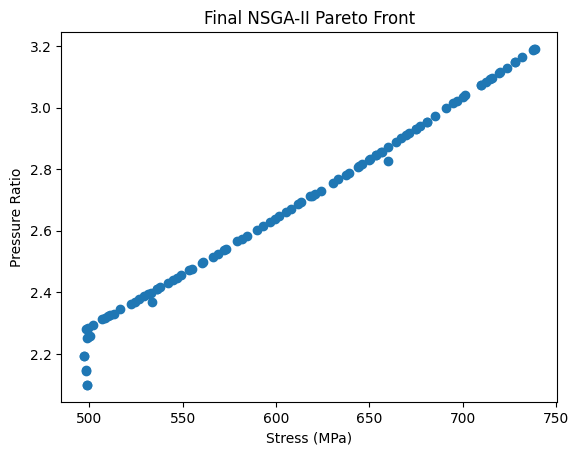

Number of Pareto optimal compressors: 100


In [ ]:
F = res.F
X = res.X

# Convert back to real objectives
PR = -F[:,0]
Stress = F[:,1]
Mach = F[:,2]
D2 = F[:,3]

import matplotlib.pyplot as plt

plt.figure()
plt.scatter(Stress/1e6, PR)
plt.xlabel("Stress (MPa)")
plt.ylabel("Pressure Ratio")
plt.title("Final NSGA-II Pareto Front")
plt.show()

print("Number of Pareto optimal compressors:", len(PR))

dimensions

In [ ]:
import numpy as np
import pandas as pd

# Get Pareto solutions
pareto_df = pd.DataFrame({
    "RPM": X[:,0],
    "psi": X[:,1],
    "Z": X[:,2],
    "phi": X[:,3],
    "PR": PR,
    "Stress": Stress,
    "Mach": Mach,
    "D2": D2
})

# Sort by PR
pareto_df = pareto_df.sort_values("PR")

# Pick middle solution
mid_index = len(pareto_df)//2
best = pareto_df.iloc[mid_index]

best
gamma = 1.4
R = 287
cp = 1005
T1 = 288
P1 = 101325
m_dot = 1.56
rho1 = P1/(R*T1)

RPM = best["RPM"]
psi = best["psi"]
Z = int(round(best["Z"]))
phi = best["phi"]
D2 = best["D2"]

omega = 2*np.pi*RPM/60
U2 = omega*(D2/2)

# Blade height from phi
b2 = m_dot/(rho1*np.pi*D2*U2*phi)

# Assume hub ratio
hub_ratio = 0.3
Dh = hub_ratio*D2
Ds = D2

print("----- FINAL COMPRESSOR DESIGN -----")
print("RPM:", RPM)
print("Tip Speed U2:", U2)
print("Impeller Diameter D2 (mm):", D2*1000)
print("Blade height b2 (mm):", b2*1000)
print("Hub Diameter (mm):", Dh*1000)
print("Blade count:", Z)
print("Loading coefficient:", psi)
print("Flow coefficient:", phi)
print("Pressure Ratio:", best["PR"])
print("Stress (MPa):", best["Stress"]/1e6)
print("Mach:", best["Mach"])

----- FINAL COMPRESSOR DESIGN -----
RPM: 42491.78444691129
Tip Speed U2: 371.41068761250153
Impeller Diameter D2 (mm): 166.93630814552307
Blade height b2 (mm): 37.08613168016179
Hub Diameter (mm): 50.08089244365692
Blade count: 16
Loading coefficient: 0.7746194490100575
Flow coefficient: 0.17616343107263419
Pressure Ratio: 2.6858363151550293
Stress (MPa): 611.986432
Mach: 1.0927735567092896


velocity triangle


In [ ]:
import numpy as np

phi = 0.17616343107263419
psi = 0.7746194490100575

beta2 = np.degrees(np.arctan(phi/(1-psi)))

print("Exit blade angle beta2 (deg):", beta2)

Exit blade angle beta2 (deg): 38.012128872187446


cad generation

In [ ]:
import numpy as np

phi = 0.17616343107263419
psi = 0.7746194490100575

beta2 = np.degrees(np.arctan(phi/(1-psi)))
beta2

# Your design
D2 = 0.16693630814552307
Dh = 0.05008089244365692
phi = 0.17616343107263419
psi = 0.7746194490100575

Rt = D2/2
Rh = Dh/2

beta2_tip = np.degrees(np.arctan(phi/(1-psi)))

phi_h = phi * (Rt/Rh)
beta2_hub = np.degrees(np.arctan(phi_h/(1-psi)))

print("Tip blade angle β2_tip:", beta2_tip)
print("Hub blade angle β2_hub:", beta2_hub)

Tip blade angle β2_tip: 38.012128872187446
Hub blade angle β2_hub: 69.00244929037615


In [ ]:
import cadquery as cq
import numpy as np

# ---- Parameters ----
D2 = 0.16693630814552307
Dh = 0.05008089244365692
b2 = 0.03708613168016179
Z = 16
phi = 0.17616343107263419
psi = 0.7746194490100575

Rt = D2/2
Rh = Dh/2

beta_tip = np.arctan(phi/(1-psi))
phi_h = phi*(Rt/Rh)
beta_hub = np.arctan(phi_h/(1-psi))

blade_thickness = 0.002

# ---- Generate Camber Curves ----
def blade_curve(radius, beta):
    theta = np.tan(beta) * np.log(radius/Rh)
    x = radius * np.cos(theta)
    y = radius * np.sin(theta)
    return (x,y)

r_vals = np.linspace(Rh, Rt, 40)

hub_pts = [blade_curve(r, beta_hub) for r in r_vals]
tip_pts = [blade_curve(r, beta_tip) for r in r_vals]

# ---- Create hub camber spline ----
hub_path = cq.Workplane("XY").spline(hub_pts)

# ---- Create blade profile at hub start ----
profile = (
    cq.Workplane("YZ")
    .workplane(offset=Rh)
    .rect(blade_thickness, blade_thickness)
)

# ---- Sweep blade from hub ----
blade = profile.sweep(hub_path, isFrenet=True)

# ---- Copy blade to tip height (twist effect) ----
blade = blade.translate((0,0,b2))

# ---- Hub and Shroud solids ----
hub = cq.Workplane("XY").circle(Rh).extrude(b2)
shroud = cq.Workplane("XY").circle(Rt).circle(Rh).extrude(b2)

assembly = hub.union(shroud)

# ---- Pattern blades ----
for i in range(Z):
    blade_instance = blade.rotate((0,0,0),(0,0,1),360/Z*i)
    assembly = assembly.union(blade_instance)

cq.exporters.export(assembly, 'ai_real_twisted_impeller.step')

from google.colab import files
files.download('ai_real_twisted_impeller.step')

print("Twisted impeller generated.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Twisted impeller generated.
